# LSTM을 이용한 교통량 예측

### 실습 목표
- 실제 도로 교통량 데이터를 전처리하는 과정을 이해합니다
- **슬라이딩 윈도우(Sliding Window)** 방식으로 시퀀스 데이터를 직접 만들어봅니다
- `nn.Module` 클래스를 직접 구현하여 **LSTM 모델**을 만들어봅니다
- 미래 교통량을 예측하고 실제값과 비교해봅니다

### Contents
1. 환경 설정
2. 데이터 불러오기
3. 데이터 전처리 (강사 설명)
4. 정규화 및 피처 선택 (직접 구현)
5. 시퀀스 데이터 생성 (직접 구현)
6. Train / Test 분할 및 DataLoader 구성
7. LSTM 모델 정의 (직접 구현)
8. 모델 학습
9. 예측 및 시각화
10. 연습 문제


## 0. 환경 설정

DL 관련 라이브러리를 불러옵니다.


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt


In [2]:
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
print(DEVICE)


cpu


## 1. 데이터 불러오기

미국 미네소타 주 고속도로(I-94)의 **시간별 교통량 데이터**를 불러옵니다.

UCI Machine Learning Repository에서 공개한 데이터로, URL 한 줄로 바로 불러올 수 있습니다.

#### 컬럼 설명
| 컬럼 | 설명 |
|---|---|
| `date_time` | 측정 시간 (시간 단위) |
| `traffic_volume` | 교통량 ← **예측 목표** |
| `temp` | 기온 (Kelvin) |
| `rain_1h` | 1시간 강수량 (mm) |
| `snow_1h` | 1시간 적설량 (mm) |
| `clouds_all` | 구름량 (%) |
| `weather_main` | 날씨 상태 (Clear, Rain, Snow 등) |
| `holiday` | 공휴일 여부 |


In [3]:
# ✅ 1. 데이터 불러오기
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
df = pd.read_csv(url)

print(f"shape : {df.shape}")
df.head()


shape : (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


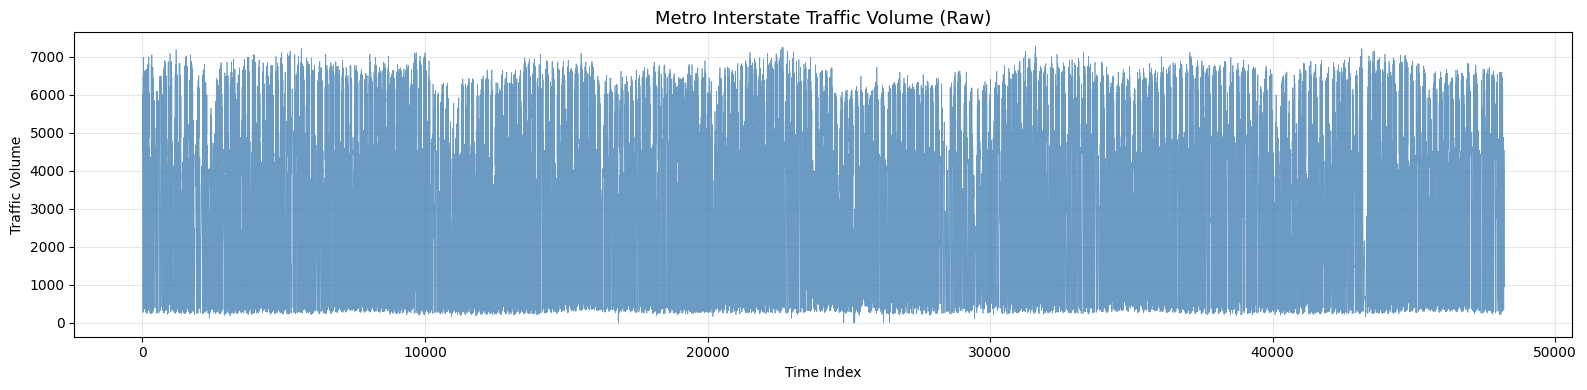

In [4]:
# ✅ 2. 교통량 시각화 (전체)
plt.figure(figsize=(16, 4))
plt.plot(df["traffic_volume"].values, color="steelblue", linewidth=0.5, alpha=0.8)
plt.title("Metro Interstate Traffic Volume (Raw)", fontsize=13)
plt.xlabel("Time Index")
plt.ylabel("Traffic Volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2. 데이터 전처리

이 데이터는 바로 사용하기 어려운 부분이 있습니다.  
아래 전처리 과정을 **강사와 함께 확인**하고 실행합니다.

---

### 2-1. datetime 파싱

`date_time` 컬럼이 문자열로 되어 있습니다.  
pandas의 `to_datetime()`으로 날짜/시간 형식으로 변환합니다.

이후 시간(hour), 요일(dayofweek) 등 유용한 피처를 추출할 수 있습니다.


In [5]:
# ✅ 3. datetime 파싱 및 시간 피처 추출 (강사 설명)
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

# 시간, 요일 피처 추출
df["hour"]      = df["date_time"].dt.hour        # 0 ~ 23
df["dayofweek"] = df["date_time"].dt.dayofweek   # 0=월요일, 6=일요일

print(df[["date_time", "hour", "dayofweek", "traffic_volume"]].head(10))


            date_time  hour  dayofweek  traffic_volume
0 2012-10-02 09:00:00     9          1            5545
1 2012-10-02 10:00:00    10          1            4516
2 2012-10-02 11:00:00    11          1            4767
3 2012-10-02 12:00:00    12          1            5026
4 2012-10-02 13:00:00    13          1            4918
5 2012-10-02 14:00:00    14          1            5181
6 2012-10-02 15:00:00    15          1            5584
7 2012-10-02 16:00:00    16          1            6015
8 2012-10-02 17:00:00    17          1            5791
9 2012-10-02 18:00:00    18          1            4770


### 2-2. 범주형 변수 인코딩

`holiday`와 `weather_main` 컬럼은 텍스트(문자열)로 되어 있습니다.  
LSTM에 입력하려면 숫자로 변환해야 합니다.

`LabelEncoder`를 사용하면 각 카테고리를 정수로 변환할 수 있습니다.

```
"None"  → 0
"Christmas Day" → 1
"Columbus Day"  → 2
...
```


In [6]:
# ✅ 4. 범주형 변수 인코딩 (강사 설명)
le_holiday = LabelEncoder()
le_weather = LabelEncoder()

df["holiday_enc"] = le_holiday.fit_transform(df["holiday"])
df["weather_enc"] = le_weather.fit_transform(df["weather_main"])

print("holiday 카테고리:", le_holiday.classes_)
print("weather 카테고리:", le_weather.classes_)


holiday 카테고리: ['Christmas Day' 'Columbus Day' 'Independence Day' 'Labor Day'
 'Martin Luther King Jr Day' 'Memorial Day' 'New Years Day' 'State Fair'
 'Thanksgiving Day' 'Veterans Day' 'Washingtons Birthday' nan]
weather 카테고리: ['Clear' 'Clouds' 'Drizzle' 'Fog' 'Haze' 'Mist' 'Rain' 'Smoke' 'Snow'
 'Squall' 'Thunderstorm']


### 2-3. 중복 및 결측치 처리

같은 시간대에 중복 기록이 있을 수 있습니다.  
`groupby`로 시간별 평균을 취해서 중복을 제거합니다.


In [7]:
# ✅ 5. 중복 시간대 처리 (강사 설명)
df = df.groupby("date_time").mean(numeric_only=True).reset_index()
df = df.dropna().reset_index(drop=True)

print(f"전처리 후 shape : {df.shape}")
df.head()


전처리 후 shape : (40575, 10)


,date_time,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,dayofweek,holiday_enc,weather_enc
0,2012-10-02 09:00:00,288.28,0.0,0.0,40.0,5545.0,9.0,1.0,11.0,1.0
1,2012-10-02 10:00:00,289.36,0.0,0.0,75.0,4516.0,10.0,1.0,11.0,1.0
2,2012-10-02 11:00:00,289.58,0.0,0.0,90.0,4767.0,11.0,1.0,11.0,1.0
3,2012-10-02 12:00:00,290.13,0.0,0.0,90.0,5026.0,12.0,1.0,11.0,1.0
4,2012-10-02 13:00:00,291.14,0.0,0.0,75.0,4918.0,13.0,1.0,11.0,1.0


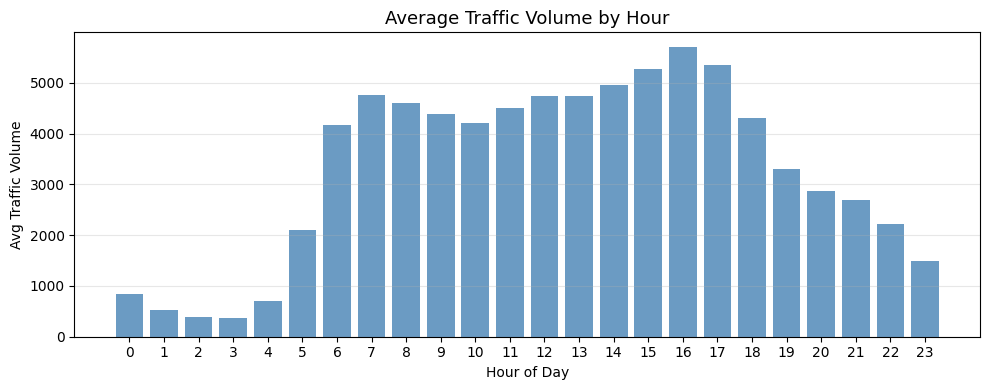

In [8]:
# ✅ 6. 시간대별 평균 교통량 시각화
hourly_avg = df.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly_avg.index, hourly_avg.values, color="steelblue", alpha=0.8)
plt.title("Average Traffic Volume by Hour", fontsize=13)
plt.xlabel("Hour of Day")
plt.ylabel("Avg Traffic Volume")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 3. 정규화 및 피처 선택

이제 직접 구현할 차례입니다!

### 사용할 피처

| 피처 | 설명 |
|---|---|
| `traffic_volume` | 교통량 ← **예측 목표이자 입력 피처** |
| `temp` | 기온 |
| `rain_1h` | 1시간 강수량 |
| `clouds_all` | 구름량 |
| `hour` | 시간대 |
| `dayofweek` | 요일 |
| `holiday_enc` | 공휴일 여부 (인코딩) |
| `weather_enc` | 날씨 상태 (인코딩) |

피처마다 값의 범위가 다르기 때문에 `MinMaxScaler`로 **0 ~ 1 정규화**합니다.


In [9]:
# ✅ 7. 사용할 피처 선택 및 정규화
feature_cols = ["traffic_volume", "temp", "rain_1h", "clouds_all",
                "hour", "dayofweek", "holiday_enc", "weather_enc"]

data = df[feature_cols].values  # numpy 배열로 변환

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print(f"data_scaled shape : {data_scaled.shape}")
print(f"값 범위 확인 — min: {data_scaled.min():.2f}, max: {data_scaled.max():.2f}")


data_scaled shape : (40575, 8)
값 범위 확인 — min: 0.00, max: 1.00


In [10]:
# ✅ 8. 입력(X)과 정답(y) 분리
#   X : 모든 피처  (8가지)
#   y : traffic_volume (교통량)  ← 첫 번째 컬럼
x = data_scaled            # shape: (N, 8)
y = data_scaled[:, 0]      # shape: (N,)   — traffic_volume

print(f"x shape : {x.shape}  →  (시간 수, 피처 수)")
print(f"y shape : {y.shape}  →  (시간 수,)")


x shape : (40575, 8)  →  (시간 수, 피처 수)
y shape : (40575,)  →  (시간 수,)


## 4. 시퀀스 데이터 생성

LSTM은 **순서가 있는 시퀀스 데이터**를 입력으로 받습니다.

**슬라이딩 윈도우(Sliding Window)** 방식으로,  
과거 `sequence_length` 시간 동안의 데이터를 보고 다음 시간의 교통량을 예측하도록  
데이터를 재구성합니다.

```
sequence_length = 24 라고 가정하면 (24시간 = 하루)

[Hour 1  ~ Hour 24]  →  예측: Hour 25 교통량
[Hour 2  ~ Hour 25]  →  예측: Hour 26 교통량
[Hour 3  ~ Hour 26]  →  예측: Hour 27 교통량
...
```


In [11]:
# ✅ 9. 슬라이딩 윈도우로 시퀀스 데이터 생성
def seq_data(x, y, sequence_length):
    """
    x               : 입력 피처 배열  (N, features)
    y               : 정답 배열       (N,)
    sequence_length : 윈도우 크기 (몇 시간치 과거 데이터를 볼지)
    """
    x_seq = []
    y_seq = []
    for i in range(len(x) - sequence_length):
        x_seq.append(x[i : i + sequence_length])   # 과거 sequence_length 시간 피처
        y_seq.append(y[i + sequence_length])        # 다음 시간 교통량

    return (
        torch.FloatTensor(x_seq).to(DEVICE),
        torch.FloatTensor(y_seq).to(DEVICE).view(-1, 1)
    )

sequence_length = 24   # 과거 24시간(하루)치를 보고 다음 시간 예측
x_seq, y_seq = seq_data(x, y, sequence_length)

print(f"x_seq shape : {x_seq.shape}  →  (샘플 수, sequence_length, 피처 수)")
print(f"y_seq shape : {y_seq.shape}  →  (샘플 수, 1)")


x_seq shape : torch.Size([40551, 24, 8])  →  (샘플 수, sequence_length, 피처 수)
y_seq shape : torch.Size([40551, 1])  →  (샘플 수, 1)


/tmp/ipykernel_2043/1231528761.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.FloatTensor(x_seq).to(DEVICE),


## 5. Train / Test 분할 및 DataLoader 구성

전체 데이터를 **학습용(80%)** 과 **테스트용(20%)** 으로 나눕니다.

> ⚠️ 시계열 데이터는 **시간 순서**를 유지해야 합니다.  
> 앞쪽(과거)을 학습에, 뒤쪽(최근)을 테스트에 사용합니다.


In [12]:
# ✅ 10. Train / Test 분할  (8 : 2, 시간 순서 유지)
split = int(len(x_seq) * 0.8)

x_train, y_train = x_seq[:split], y_seq[:split]
x_test,  y_test  = x_seq[split:], y_seq[split:]

print(f"학습 데이터  : {x_train.shape}, {y_train.shape}")
print(f"테스트 데이터: {x_test.shape},  {y_test.shape}")


학습 데이터  : torch.Size([32440, 24, 8]), torch.Size([32440, 1])
테스트 데이터: torch.Size([8111, 24, 8]),  torch.Size([8111, 1])


In [13]:
# ✅ 11. DataLoader 구성
batch_size = 32

train_dataset = TensorDataset(x_train, y_train)
test_dataset  = TensorDataset(x_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"train_loader 배치 수 : {len(train_loader)}")
print(f"test_loader  배치 수 : {len(test_loader)}")


train_loader 배치 수 : 1014
test_loader  배치 수 : 254


## 6. LSTM 모델 정의

앞서 주가 예측 실습에서 사용한 `VanillaLSTM`과 **구조가 동일**합니다.  
직접 작성해보세요!

### 핵심 파라미터 (`nn.LSTM`)

| 파라미터 | 설명 |
|---|---|
| `input_size` | 입력 피처 수 (8가지 피처) |
| `hidden_size` | hidden state의 크기 (자유롭게 설정) |
| `num_layers` | LSTM 레이어 층 수 |
| `batch_first=True` | 입력 텐서의 첫 번째 차원을 batch로 처리 |

### forward() 흐름

```
입력 x : (batch, sequence_length, input_size)
   ↓  h0, c0 초기화 (0으로)
   ↓  LSTM 통과
   out : (batch, sequence_length, hidden_size)
   ↓  flatten : (batch, sequence_length * hidden_size)
   ↓  FC + Sigmoid
출력 : (batch, 1)  ← 정규화된 교통량 예측값
```


In [14]:
# ✅ 12. LSTM 모델 정의
class VanillaLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, sequence_length, num_layers, device):
        super(VanillaLSTM, self).__init__()
        self.device      = device
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # LSTM 레이어
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # 출력 레이어
        # traffic_volume은 MinMaxScaler로 0~1 정규화되어 있으므로 Sigmoid 사용
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * sequence_length, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # hidden state와 cell state를 0으로 초기화
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)

        # LSTM 통과
        out, _ = self.lstm(x, (h0, c0))

        # flatten 후 FC 레이어
        out = out.reshape(out.shape[0], -1)
        out = self.fc(out)
        return out


## 7. 모델 학습

하이퍼파라미터를 설정하고 모델을 학습합니다.

| 항목 | 설명 |
|---|---|
| `input_size` | 입력 피처 수 (x_seq의 마지막 차원) |
| `hidden_size` | LSTM hidden state 크기 |
| `num_layers` | LSTM 층 수 |
| `criterion` | 손실 함수 — 회귀 문제이므로 MSELoss 사용 |
| `optimizer` | Adam 최적화 |


In [15]:
# ✅ 13. 하이퍼파라미터 설정 및 모델 생성
input_size  = x_seq.size(2)   # 8  (피처 수)
hidden_size = 16
num_layers  = 2
num_epochs  = 30              # 데이터가 크므로 epoch 수를 줄입니다

model     = VanillaLSTM(input_size, hidden_size, sequence_length, num_layers, DEVICE).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)


VanillaLSTM(
  (lstm): LSTM(8, 16, num_layers=2, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=384, out_features=1, bias=True)
    (1): Sigmoid()
  )
)


In [16]:
# ✅ 14. 모델 학습
loss_graph = []
n = len(train_loader)

model.train()
for epoch in range(num_epochs):
    running_loss = 0

    for seq, target in train_loader:
        out  = model(seq)
        loss = criterion(out, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / n
    loss_graph.append(avg_loss)

    if epoch % 5 == 0:
        print(f"[epoch {epoch:3d}]  loss: {avg_loss:.4f}")


[epoch   0]  loss: 0.0214
[epoch   5]  loss: 0.0046
[epoch  10]  loss: 0.0040
[epoch  15]  loss: 0.0037
[epoch  20]  loss: 0.0035
[epoch  25]  loss: 0.0033


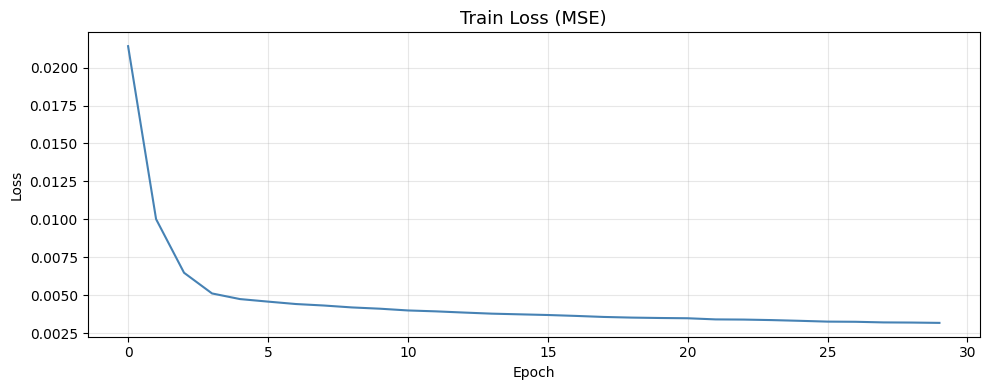

In [17]:
# ✅ 15. Loss 그래프
plt.figure(figsize=(10, 4))
plt.plot(loss_graph, color="steelblue", linewidth=1.5)
plt.title("Train Loss (MSE)", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. 예측 및 시각화

학습이 끝난 모델로 전체 데이터(학습 + 테스트)에 대한 예측을 수행하고,  
실제 교통량과 비교해봅니다.

세로 점선의 **왼쪽이 학습 구간**, 오른쪽이 **테스트 구간**입니다.


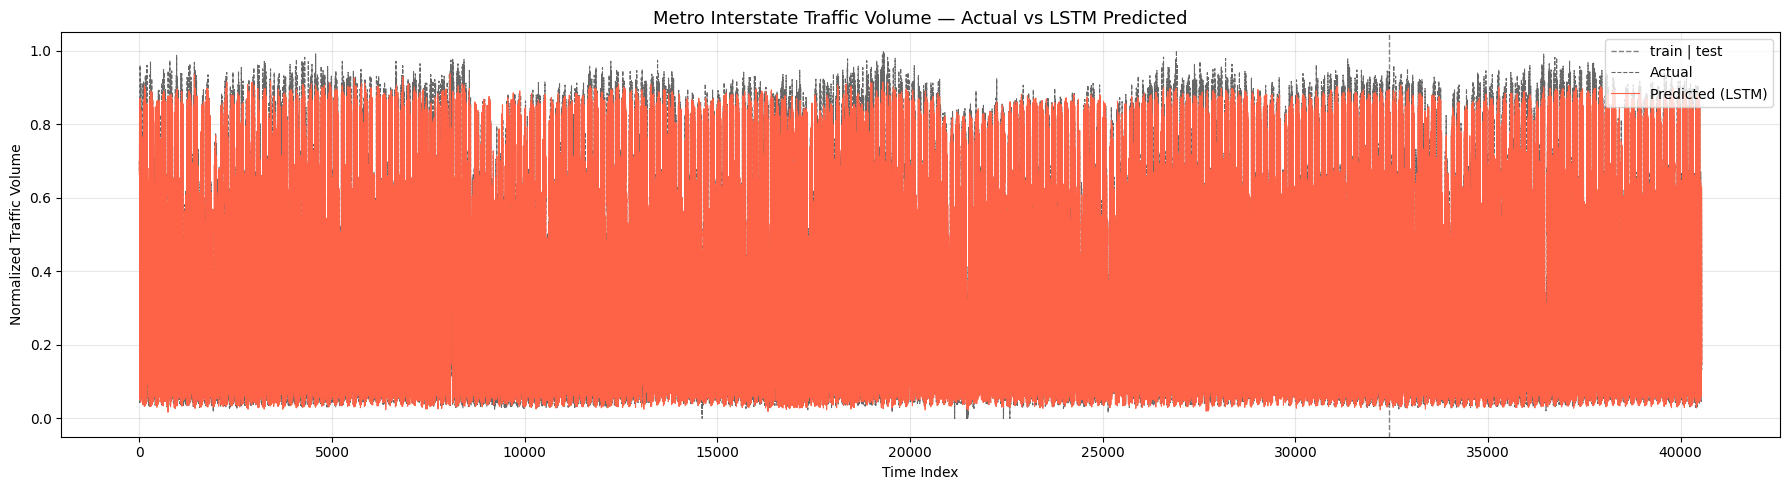

In [18]:
# ✅ 16. 전체 데이터 예측 및 시각화
concat_dataset = TensorDataset(x_seq, y_seq)
data_loader    = DataLoader(concat_dataset, batch_size=256)

with torch.no_grad():
    pred = []
    model.eval()
    for seq, target in data_loader:
        out = model(seq)
        pred += out.cpu().tolist()

plt.figure(figsize=(18, 5))
plt.axvline(x=split, color="gray", linestyle="--", linewidth=1, label="train | test")
plt.plot(y[sequence_length:], "--", color="black", linewidth=0.8, alpha=0.6, label="Actual")
plt.plot(pred, color="tomato", linewidth=0.8, label="Predicted (LSTM)")
plt.title("Metro Interstate Traffic Volume — Actual vs LSTM Predicted", fontsize=13)
plt.xlabel("Time Index")
plt.ylabel("Normalized Traffic Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


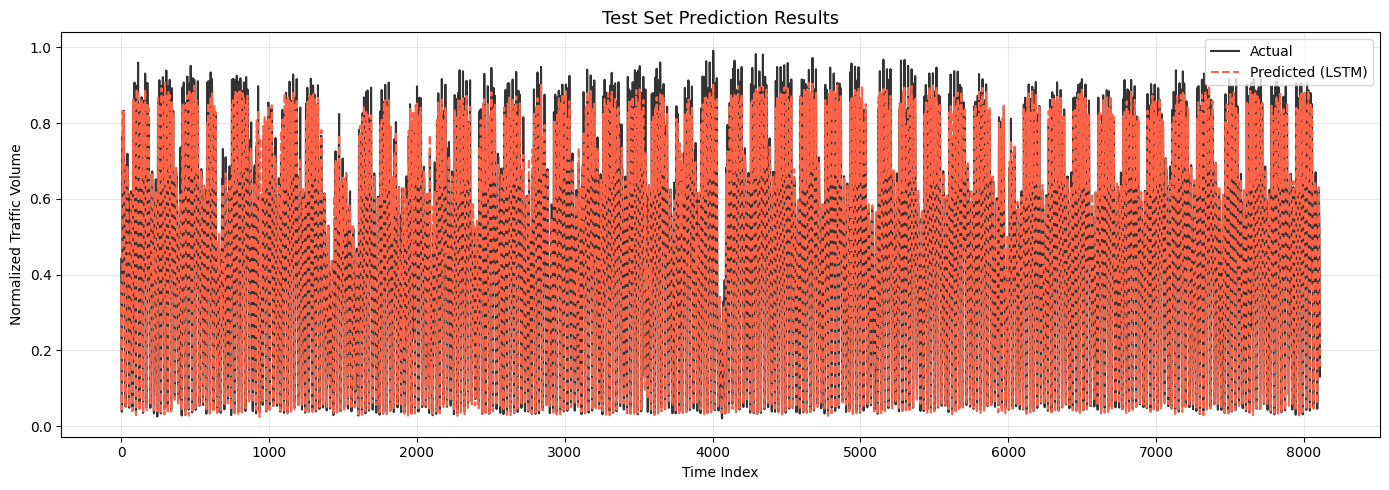


📊 테스트 MSE : 0.001266


In [19]:
# ✅ 17. 테스트 구간만 따로 시각화
test_true = y_test.cpu().numpy().flatten()
test_pred = []

with torch.no_grad():
    model.eval()
    for seq, target in test_loader:
        out = model(seq)
        test_pred += out.cpu().tolist()

test_pred = np.array(test_pred).flatten()

plt.figure(figsize=(14, 5))
plt.plot(test_true, label="Actual",           color="black",  linewidth=1.5, alpha=0.8)
plt.plot(test_pred, label="Predicted (LSTM)", color="tomato", linewidth=1.5, linestyle="--")
plt.title("Test Set Prediction Results", fontsize=13)
plt.xlabel("Time Index")
plt.ylabel("Normalized Traffic Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

test_mse = np.mean((test_pred - test_true) ** 2)
print(f"\n📊 테스트 MSE : {test_mse:.6f}")


## 9. 연습 문제

### Exercise 1 — 하이퍼파라미터 조정

아래 값들을 바꿔가며 MSE 변화를 확인해보세요.

1. `sequence_length` : 24 → 6, 12, 48
2. `hidden_size` : 16 → 8, 32, 64
3. `num_layers` : 2 → 1, 3
4. `lr` : 1e-3 → 1e-4, 1e-2

### Exercise 2 — 피처 조합 변경

사용하는 피처를 바꿔보면 성능이 달라질까요?  
아래처럼 피처를 줄이거나 늘려서 MSE를 비교해보세요.

```python
# 기상 관련 피처만 사용
feature_cols = ["traffic_volume", "temp", "rain_1h", "clouds_all"]

# 시간 관련 피처만 사용
feature_cols = ["traffic_volume", "hour", "dayofweek", "holiday_enc"]
```

### 💬 생각해볼 점

> 출퇴근 시간대(오전 8시, 오후 6시)의 교통량은 특히 예측하기 어렵습니다.  
> 이런 **급격한 변화 구간**을 더 잘 예측하려면 어떻게 해야 할까요?


[epoch   0]  loss: 0.0221
[epoch  10]  loss: 0.0038
[epoch  20]  loss: 0.0033

📊 Test MSE : 0.001275  (seq=24, hidden=16, layers=2)


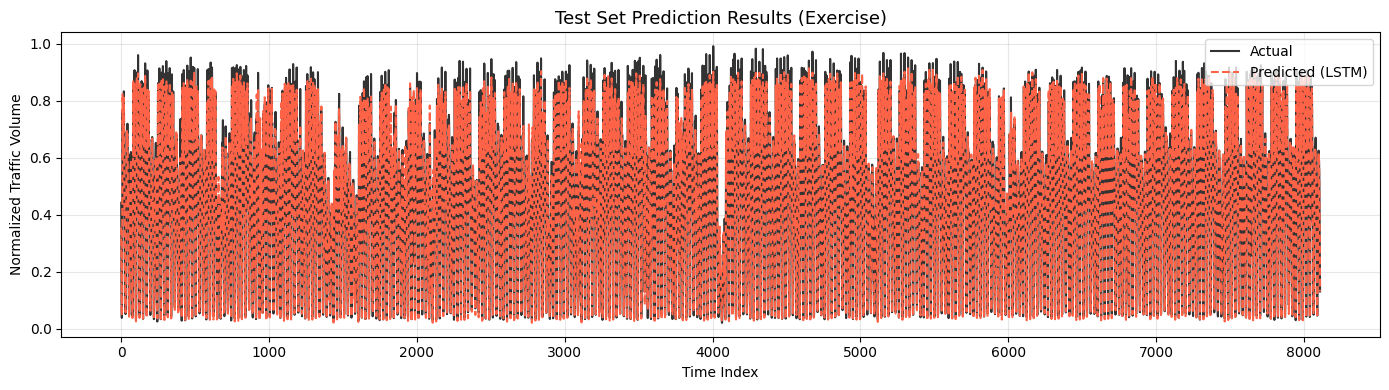

In [20]:
# ✅ [Exercise] 하이퍼파라미터를 바꿔가며 실험해보세요!

# ── 변경 가능한 파라미터 ───────────────────────────────────────
sequence_length_ex = 24   # ← 바꿔보세요: 6, 12, 48
hidden_size_ex     = 16   # ← 바꿔보세요: 8, 32, 64
num_layers_ex      = 2    # ← 바꿔보세요: 1, 3
lr_ex              = 1e-3 # ← 바꿔보세요: 1e-4, 1e-2

# ── 피처 조합도 바꿔보세요 ─────────────────────────────────────
feature_cols_ex = ["traffic_volume", "temp", "rain_1h", "clouds_all",
                   "hour", "dayofweek", "holiday_enc", "weather_enc"]
# ──────────────────────────────────────────────────────────────

data_ex        = df[feature_cols_ex].values
data_scaled_ex = MinMaxScaler().fit_transform(data_ex)
x_ex           = data_scaled_ex
y_ex           = data_scaled_ex[:, 0]

x_seq_ex, y_seq_ex = seq_data(x_ex, y_ex, sequence_length_ex)
split_ex = int(len(x_seq_ex) * 0.8)

x_train_ex, y_train_ex = x_seq_ex[:split_ex], y_seq_ex[:split_ex]
x_test_ex,  y_test_ex  = x_seq_ex[split_ex:], y_seq_ex[split_ex:]

train_loader_ex = DataLoader(TensorDataset(x_train_ex, y_train_ex), batch_size=32, shuffle=True)
test_loader_ex  = DataLoader(TensorDataset(x_test_ex,  y_test_ex),  batch_size=32, shuffle=False)

model_ex     = VanillaLSTM(x_seq_ex.size(2), hidden_size_ex, sequence_length_ex, num_layers_ex, DEVICE).to(DEVICE)
optimizer_ex = optim.Adam(model_ex.parameters(), lr=lr_ex)
criterion_ex = nn.MSELoss()

model_ex.train()
for epoch in range(30):
    running_loss = 0
    for seq, target in train_loader_ex:
        out  = model_ex(seq)
        loss = criterion_ex(out, target)
        optimizer_ex.zero_grad()
        loss.backward()
        optimizer_ex.step()
        running_loss += loss.item()
    if epoch % 10 == 0:
        print(f"[epoch {epoch:3d}]  loss: {running_loss/len(train_loader_ex):.4f}")

model_ex.eval()
with torch.no_grad():
    pred_ex, true_ex = [], []
    for seq, target in test_loader_ex:
        pred_ex += model_ex(seq).cpu().tolist()
        true_ex += target.cpu().tolist()

pred_ex = np.array(pred_ex).flatten()
true_ex = np.array(true_ex).flatten()
mse_ex  = np.mean((pred_ex - true_ex) ** 2)
print(f"\n📊 Test MSE : {mse_ex:.6f}  "
      f"(seq={sequence_length_ex}, hidden={hidden_size_ex}, layers={num_layers_ex})")

plt.figure(figsize=(14, 4))
plt.plot(true_ex, label="Actual",           color="black",  linewidth=1.5, alpha=0.8)
plt.plot(pred_ex, label="Predicted (LSTM)", color="tomato", linewidth=1.5, linestyle="--")
plt.title("Test Set Prediction Results (Exercise)", fontsize=13)
plt.xlabel("Time Index")
plt.ylabel("Normalized Traffic Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
